<a href="https://colab.research.google.com/github/Naganarthanan/RiceGuard-DL/blob/mathusan/model3_Resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive to access the shared dataset
from google.colab import auth
auth.authenticate_user()

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os

# This should be the same path structure as the shared folder
drive_target = '/content/drive/MyDrive/RiceGuard_DL/rice_disease_split'

# Check if the directory exists before trying to list its contents
if not os.path.exists(drive_target):
    print(f"Error: Directory not found at {drive_target}")
    print("Please verify the path in your Google Drive.")
else:
    print("Contents:", os.listdir(drive_target))

    for split in ['train', 'val', 'test']:
        path = os.path.join(drive_target, split)
        if not os.path.exists(path):
            print(f"Error: Split directory '{split}' not found at {path}")
        else:
            print(f"{split}: {sorted(os.listdir(path))}")

Contents: ['custom_cnn_best.h5', 'test', 'train', 'val']
train: ['Bacterial_Leaf_Blight', 'Brown_Spot', 'Healthy_Rice_Leaf', 'Leaf_Blast', 'Leaf_scald', 'Sheath_Blight']
val: ['Bacterial_Leaf_Blight', 'Brown_Spot', 'Healthy_Rice_Leaf', 'Leaf_Blast', 'Leaf_scald', 'Sheath_Blight']
test: ['Bacterial_Leaf_Blight', 'Brown_Spot', 'Healthy_Rice_Leaf', 'Leaf_Blast', 'Leaf_scald', 'Sheath_Blight']


In [3]:
import os
print(os.listdir('/content/drive/MyDrive/RiceGuard_DL/rice_disease_split'))

['custom_cnn_best.h5', 'test', 'train', 'val']


In [4]:
import os
print(os.listdir('/content/drive/MyDrive/RiceGuard_DL'))

['rice_disease_split']


In [5]:
import os
print(os.listdir('/content/drive/MyDrive'))

['IMG-20230114-WA0019.jpg', 'IMG-20230114-WA0018.jpg', 'IMG-20230107-WA0013.jpg', 'IMG-20230114-WA0020.jpg', 'Screenshot_2023-01-14-14-27-57-64_f9ee0578fe1cc94de7482bd41accb329 (1).jpg', 'Screenshot_2023-01-14-14-27-57-64_f9ee0578fe1cc94de7482bd41accb329.jpg', 'SPEECH CS 2023-JUN.gsheet', 'Draw an activity diagram for this.gsheet', '8a43af3b-ab4a-4837-924b-961d4a8d8f12.jpeg', 'ada540d6-c049-4b33-bd02-58ba80d6462a.jpeg', 'IMG_3550.png', 'Mathusan_Kumarakuru_CV (1).pdf', 'IT23167414_StudentPerformanceProfile.pdf', 'Mathusan_Kumarakuru_CV.pdf', 'DL_Lab2', 'Colab Notebooks', 'Lab Materials', 'CommonDataSetForRiceGuard.ipynb', 'RiceGuard_DL']


In [6]:
import os

# Check what's directly in MyDrive
print("Top-level folders in My Drive:")
print(os.listdir('/content/drive/MyDrive'))

Top-level folders in My Drive:
['IMG-20230114-WA0019.jpg', 'IMG-20230114-WA0018.jpg', 'IMG-20230107-WA0013.jpg', 'IMG-20230114-WA0020.jpg', 'Screenshot_2023-01-14-14-27-57-64_f9ee0578fe1cc94de7482bd41accb329 (1).jpg', 'Screenshot_2023-01-14-14-27-57-64_f9ee0578fe1cc94de7482bd41accb329.jpg', 'SPEECH CS 2023-JUN.gsheet', 'Draw an activity diagram for this.gsheet', '8a43af3b-ab4a-4837-924b-961d4a8d8f12.jpeg', 'ada540d6-c049-4b33-bd02-58ba80d6462a.jpeg', 'IMG_3550.png', 'Mathusan_Kumarakuru_CV (1).pdf', 'IT23167414_StudentPerformanceProfile.pdf', 'Mathusan_Kumarakuru_CV.pdf', 'DL_Lab2', 'Colab Notebooks', 'Lab Materials', 'CommonDataSetForRiceGuard.ipynb', 'RiceGuard_DL']


In [9]:
import shutil
import time
import os # Import os for path checking

# Copying from Drive to local disk significantly speeds up training
# (Drive I/O is slow when reading thousands of small files directly)
start = time.time()

local_path = '/content/RiceGuard_DL/rice_disease_split'

# Verify if the drive_target path exists before attempting to copy
if os.path.exists(drive_target):
    # Remove local_path if it already exists to avoid DirectoryExistsError
    if os.path.exists(local_path):
        shutil.rmtree(local_path)

    shutil.copytree(drive_target, local_path)

    end = time.time()
    print(f"Copy time: {(end-start)/60:.2f} minutes")
    print("Copied to:", local_path)
else:
    print(f"Error: Source directory '{drive_target}' not found in Google Drive. ")
    print("Please verify the path and update the 'drive_target' variable in cell `AhReTyQ8Tgk2`.")

Copy time: 0.23 minutes
Copied to: /content/RiceGuard_DL/rice_disease_split


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = f'{local_path}/train'
val_dir = f'{local_path}/val'
test_dir = f'{local_path}/test'

# ResNet50-specific preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_data.class_indices)

print("Classes:", train_data.class_indices)
print("Number of classes:", num_classes)
print("Train samples:", train_data.samples)
print("Val samples:", val_data.samples)
print("Test samples:", test_data.samples)

Found 2655 images belonging to 6 classes.
Found 567 images belonging to 6 classes.
Found 576 images belonging to 6 classes.
Classes: {'Bacterial_Leaf_Blight': 0, 'Brown_Spot': 1, 'Healthy_Rice_Leaf': 2, 'Leaf_Blast': 3, 'Leaf_scald': 4, 'Sheath_Blight': 5}
Number of classes: 6
Train samples: 2655
Val samples: 567
Test samples: 576


In [15]:
import os

# Define train_dir again for clarity in this snippet, though it's already defined.
# Ensure local_path is correctly populated from the data copying step.
local_path = '/content/RiceGuard_DL/rice_disease_split'
train_dir = os.path.join(local_path, 'train')

if os.path.exists(train_dir):
    # Count subdirectories in the train_dir as classes
    num_classes = len([name for name in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, name))])
    print(f"Number of classes found: {num_classes}")
else:
    print(f"Error: Training directory not found at {train_dir}")
    print("Please ensure the 'rice_disease_split' dataset has been successfully copied to the local environment.")
    # Set num_classes to a default or raise an error if you want to stop execution
    # For now, we'll keep it undefined or set to 0 to make the error explicit later if not fixed.
    num_classes = 0 # Or you could raise an exception here


Number of classes found: 6


Let's write a script to help you locate the `rice_disease_split` folder within your Google Drive. This function will recursively search for the folder and return its path if found.

In [16]:
import os

def find_folder(root_dir, folder_name):
    """Recursively searches for a folder with a given name starting from root_dir."""
    for dirpath, dirnames, filenames in os.walk(root_dir):
        if folder_name in dirnames:
            return os.path.join(dirpath, folder_name)
    return None

search_start_path = '/content/drive/MyDrive' # Changed to search entire My Drive
target_folder_name = 'rice_disease_split'

print(f"Searching for '{target_folder_name}' starting from '{search_start_path}'...")
found_path = find_folder(search_start_path, target_folder_name)

if found_path:
    print(f"Found '{target_folder_name}' at: {found_path}")
    print("\nNow, please update the `drive_target` variable in cell `AhReTyQ8Tgk2` with this path:")
    print(f"`drive_target = '{found_path}'`")
    print("Then, run cell `AhReTyQ8Tgk2` again, followed by cell `IX1bPqiIXYS-` to copy the data, and finally cell `8KnlCByEYABs`.")
else:
    print(f"'{target_folder_name}' not found within '{search_start_path}'.")
    print("\nIt might be in a different location in your Google Drive. You can manually browse your Drive or ensure it's shared correctly and accessible.")


Searching for 'rice_disease_split' starting from '/content/drive/MyDrive'...
Found 'rice_disease_split' at: /content/drive/MyDrive/RiceGuard_DL/rice_disease_split

Now, please update the `drive_target` variable in cell `AhReTyQ8Tgk2` with this path:
`drive_target = '/content/drive/MyDrive/RiceGuard_DL/rice_disease_split'`
Then, run cell `AhReTyQ8Tgk2` again, followed by cell `IX1bPqiIXYS-` to copy the data, and finally cell `8KnlCByEYABs`.


In [17]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pre-trained ResNet50 (trained on ImageNet)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,          # exclude the original classification layer
    input_shape=(224, 224, 3)
)

# Freeze the base model layers (keep pre-trained weights unchanged)
base_model.trainable = False

# Add custom classification head for our 6 rice disease classes
resnet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,926 (92.11 MB)

 Trainable params: 558,214 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('resnet50_best.h5', monitor='val_accuracy', save_best_only=True)

history = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.2035 - loss: 2.0863

83/83 ━━━━━━━━━━━━━━━━━━━━ 96s 966ms/step - accuracy: 0.2783 - loss: 1.8186 - val_accuracy: 0.5750 - val_loss: 1.3374
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.4498 - loss: 1.4294

83/83 ━━━━━━━━━━━━━━━━━━━━ 62s 744ms/step - accuracy: 0.4757 - loss: 1.3752 - val_accuracy: 0.6102 - val_loss: 1.1108
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.5261 - loss: 1.2499

83/83 ━━━━━━━━━━━━━━━━━━━━ 64s 761ms/step - accuracy: 0.5326 - loss: 1.2304 - val_accuracy: 0.6667 - val_loss: 0.9499
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.5823 - loss: 1.1284

83/83 ━━━━━━━━━━━━━━━━━━━━ 63s 756ms/step - accuracy: 0.6064 - loss: 1.0891 - val_accuracy: 0.7037 - val_loss: 0.8680
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.6012 - loss: 1.0373

...

83/83 ━━━━━━━━━━━━━━━━━━━━ 63s 755ms/step - accuracy: 0.7284 - loss: 0.7534 - val_accuracy: 0.7601 - val_loss: 0.6634
Epoch 11/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.7323 - loss: 0.7605

83/83 ━━━━━━━━━━━━━━━━━━━━ 62s 743ms/step - accuracy: 0.7307 - loss: 0.7481 - val_accuracy: 0.7901 - val_loss: 0.6248
Epoch 12/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.7423 - loss: 0.7345

83/83 ━━━━━━━━━━━━━━━━━━━━ 81s 738ms/step - accuracy: 0.7420 - loss: 0.7076 - val_accuracy: 0.7954 - val_loss: 0.6089
Epoch 13/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.7559 - loss: 0.6552

83/83 ━━━━━━━━━━━━━━━━━━━━ 61s 733ms/step - accuracy: 0.7571 - loss: 0.6598 - val_accuracy: 0.8007 - val_loss: 0.5740
Epoch 14/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 64s 768ms/step - accuracy: 0.7559 - loss: 0.6552 - val_accuracy: 0.7919 - val_loss: 0.5763
Epoch 15/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.7773 - loss: 0.6022

83/83 ━━━━━━━━━━━━━━━━━━━━ 60s 718ms/step - accuracy: 0.7740 - loss: 0.6151 - val_accuracy: 0.8148 - val_loss: 0.5466


In [19]:
# Unfreeze the last 20 layers of the base model for fine-tuning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a much lower learning rate for fine-tuning
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 101s 973ms/step - accuracy: 0.7443 - loss: 0.7006 - val_accuracy: 0.7795 - val_loss: 0.5673
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.7837 - loss: 0.6289

83/83 ━━━━━━━━━━━━━━━━━━━━ 64s 774ms/step - accuracy: 0.7857 - loss: 0.5991 - val_accuracy: 0.8254 - val_loss: 0.5114
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.8140 - loss: 0.5482

83/83 ━━━━━━━━━━━━━━━━━━━━ 65s 789ms/step - accuracy: 0.8124 - loss: 0.5457 - val_accuracy: 0.8342 - val_loss: 0.4727
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.8256 - loss: 0.5011

83/83 ━━━━━━━━━━━━━━━━━━━━ 65s 778ms/step - accuracy: 0.8234 - loss: 0.5074 - val_accuracy: 0.8483 - val_loss: 0.4412
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.8209 - loss: 0.5054

83/83 ━━━━━━━━━━━━━━━━━━━━ 64s 769ms/step - accuracy: 0.8267 - loss: 0.4807 - val_accuracy: 0.8519 - val_loss: 0.4143
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.8436 - loss: 0.4363

83/83 ━━━━━━━━━━━━━━━━━━━━ 65s 788ms/step - accuracy: 0.8463 - loss: 0.4278 - val_accuracy: 0.8624 - val_loss: 0.3924
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.8539 - loss: 0.4211

83/83 ━━━━━━━━━━━━━━━━━━━━ 63s 762ms/step - accuracy: 0.8640 - loss: 0.4078 - val_accuracy: 0.8713 - val_loss: 0.3778
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.8515 - loss: 0.4067

83/83 ━━━━━━━━━━━━━━━━━━━━ 61s 734ms/step - accuracy: 0.8584 - loss: 0.4084 - val_accuracy: 0.8801 - val_loss: 0.3571
Epoch 9/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.8633 - loss: 0.3867

83/83 ━━━━━━━━━━━━━━━━━━━━ 70s 845ms/step - accuracy: 0.8659 - loss: 0.3814 - val_accuracy: 0.8942 - val_loss: 0.3390
Epoch 10/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 66s 799ms/step - accuracy: 0.8757 - loss: 0.3590 - val_accuracy: 0.8889 - val_loss: 0.3252


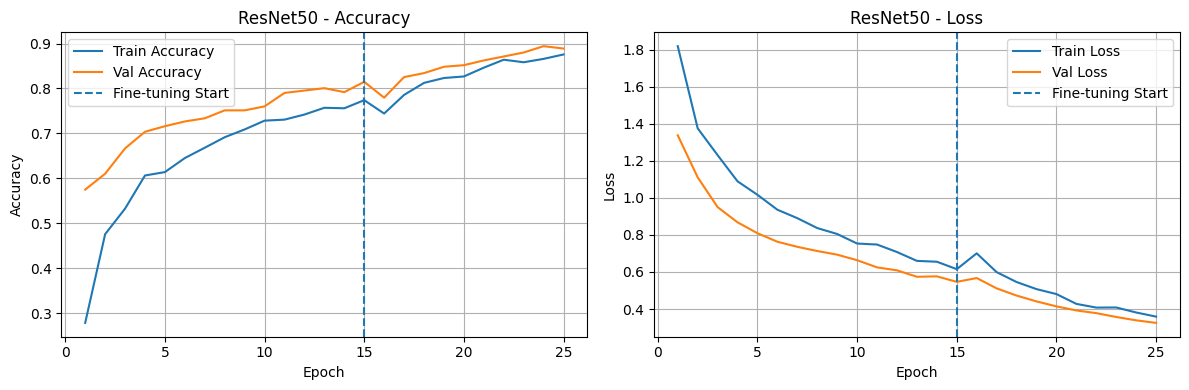

In [20]:
import matplotlib.pyplot as plt

# Combine initial training + fine-tuning results
train_accuracy = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_accuracy = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

train_loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

# Total number of epochs actually completed
epochs = range(1, len(train_accuracy) + 1)

# Fine-tuning starts after initial training
fine_tune_start = len(history.history['accuracy'])

plt.figure(figsize=(12, 4))

# ---------------- Accuracy ----------------
plt.subplot(1, 2, 1)

plt.plot(epochs, train_accuracy, label='Train Accuracy')
plt.plot(epochs, val_accuracy, label='Val Accuracy')

# Show where fine-tuning started
plt.axvline(
    x=fine_tune_start,
    linestyle='--',
    label='Fine-tuning Start'
)

plt.title('ResNet50 - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# ---------------- Loss ----------------
plt.subplot(1, 2, 2)

plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')

# Show where fine-tuning started
plt.axvline(
    x=fine_tune_start,
    linestyle='--',
    label='Fine-tuning Start'
)

plt.title('ResNet50 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    'resnet50_training_and_finetuning_curves.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [21]:
test_loss, test_accuracy = resnet_model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 350ms/step - accuracy: 0.8976 - loss: 0.2985
Test Accuracy: 89.76%
Test Loss: 0.2985


18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 259ms/step
                       precision    recall  f1-score   support

Bacterial_Leaf_Blight       0.83      0.85      0.84        96
           Brown_Spot       0.87      0.94      0.90        97
    Healthy_Rice_Leaf       0.97      0.98      0.97        99
           Leaf_Blast       0.90      0.76      0.82        94
           Leaf_scald       0.90      0.91      0.90        95
        Sheath_Blight       0.93      0.95      0.94        95

             accuracy                           0.90       576
            macro avg       0.90      0.90      0.90       576
         weighted avg       0.90      0.90      0.90       576



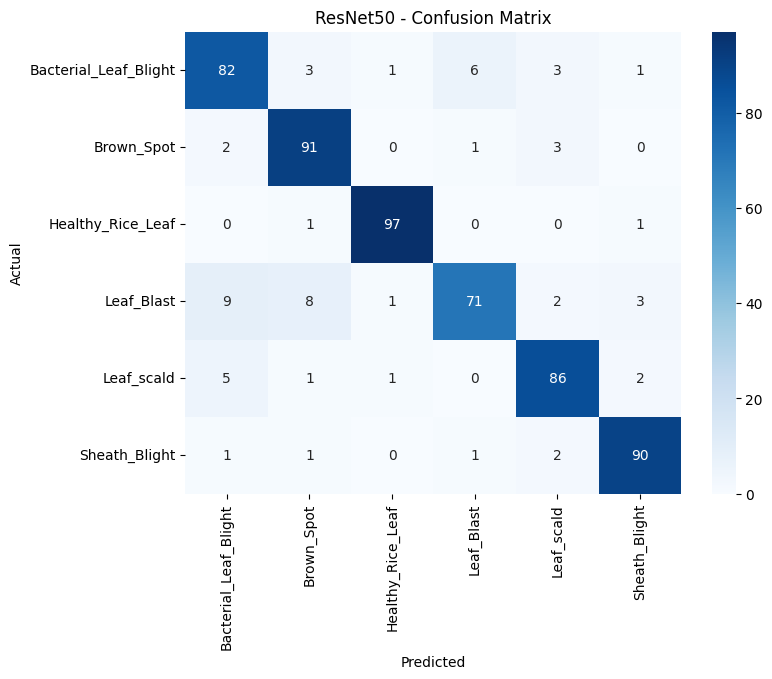

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

predictions = resnet_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('ResNet50 - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('resnet50_confusion_matrix.png')
plt.show()

In [23]:
# Save to the shared Drive folder so it's accessible to the whole team
os.makedirs('/content/drive/MyDrive/RiceGuard_DL/models', exist_ok=True)
resnet_model.save('/content/drive/MyDrive/RiceGuard_DL/models/resnet50_final.h5')
print("Model saved to Drive!")

Model saved to Drive!
